In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df=pd.read_csv("C:\\Users\\Jeevan\\OneDrive\\Desktop\\ITV DA AND DS\\PROJECT\\ML PROJECT\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Basic info
print(df.shape)
print(df.info())
print(df['Churn'].value_counts(normalize=True))

# Data Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID (not useful for modeling)
df = df.drop('customerID', axis=1)

# Convert SeniorCitizen to categorical string for better plotting
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("Missing values:", df.isnull().sum().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [14]:
# Churn rate by key categories
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']

for col in cat_cols:
    print(f"\n=== {col} vs Churn ===")
    print(pd.crosstab(df[col], df['Churn'], normalize='index'))


=== gender vs Churn ===
Churn         No       Yes
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603

=== SeniorCitizen vs Churn ===
Churn                No       Yes
SeniorCitizen                    
No             0.763938  0.236062
Yes            0.583187  0.416813

=== Partner vs Churn ===
Churn          No       Yes
Partner                    
No       0.670420  0.329580
Yes      0.803351  0.196649

=== Dependents vs Churn ===
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502

=== PhoneService vs Churn ===
Churn               No       Yes
PhoneService                    
No            0.750733  0.249267
Yes           0.732904  0.267096

=== MultipleLines vs Churn ===
Churn                   No       Yes
MultipleLines                       
No                0.749558  0.250442
No phone service  0.750733  0.249267
Yes               0.713901  0.286099

=== InternetService vs Chur

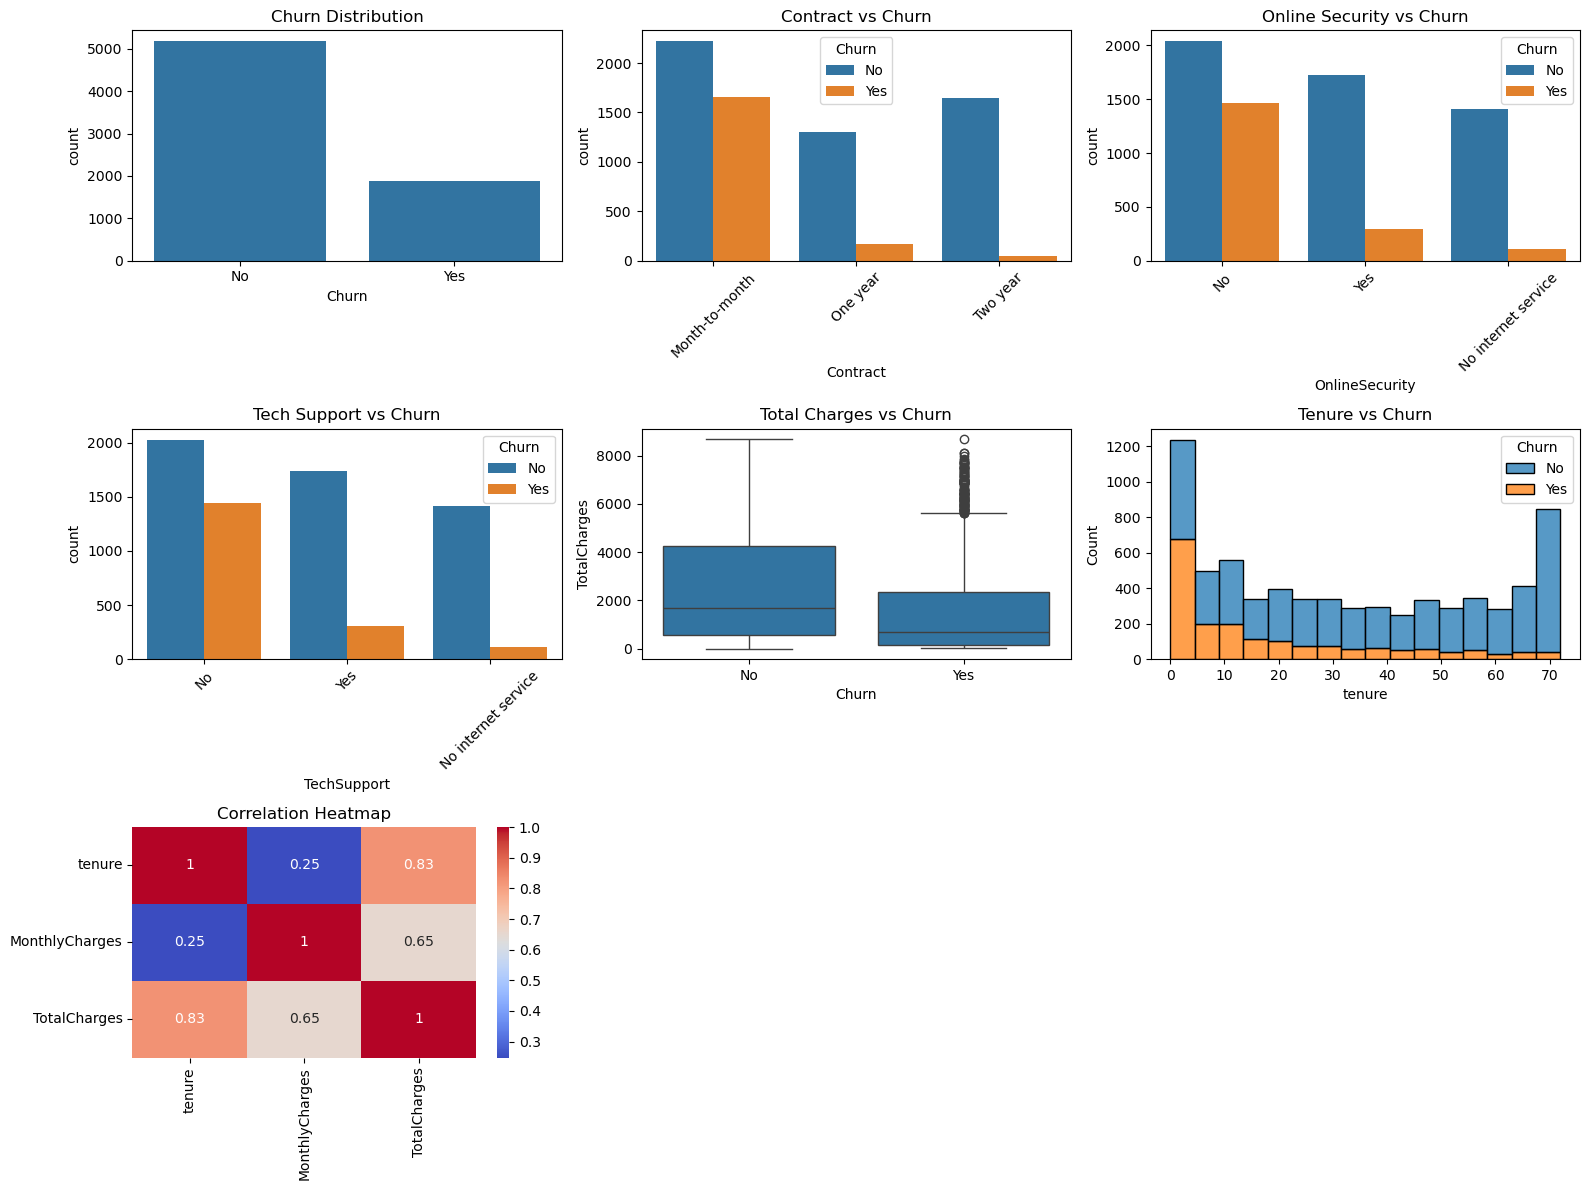

In [15]:
#Exploratory Data Analysis (EDA)
plt.figure(figsize=(16,12))

# 1. Churn Distribution
plt.subplot(3,3,1)
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')

# 2. Contract vs Churn
plt.subplot(3,3,2)
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract vs Churn')
plt.xticks(rotation=45)


# 3. Online Security vs Churn
plt.subplot(3,3,3)
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.title('Online Security vs Churn')
plt.xticks(rotation=45)

# 4. Tech Support vs Churn
plt.subplot(3,3,4)
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('Tech Support vs Churn')
plt.xticks(rotation=45)

# 5. Total Charges vs Churn
plt.subplot(3,3,5)
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('Total Charges vs Churn')

# 6. Tenure vs Churn
plt.subplot(3,3,6)
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')
plt.title('Tenure vs Churn')

#7.Correlation Heatmap
plt.subplot(3,3,7)
num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
sns.heatmap(num_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [16]:
#Numerical Summary
print(df.describe())

#Features & Target Separate
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes':1, 'No':0})

#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#Find Categorical & Numerical Columns
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=['int64','float64']).columns.tolist()

print(cat_features)
print(num_features)

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
['tenure', 'MonthlyCharges', 'TotalCharges']


In [17]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()
for col in cat_features:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train[col])
    X_test_enc[col] = le.transform(X_test[col])

In [18]:
#Model Building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
# Models
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}
# Hyperparameter Grids
param_grids = {
    'DecisionTree': {
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    },

    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, None]
    },

    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [5, 7],
        'learning_rate': [0.1, 0.2]
    }
}
best_models = {}
results = {}
for name, model in models.items():
    print(f"\nTuning {name}...")
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    # Train model
    grid.fit(X_train_enc, y_train)
    # Best model
    best_models[name] = grid.best_estimator_
    # Prediction
    y_pred = grid.predict(X_test_enc)
    # Probability
    y_pred_proba = grid.predict_proba(X_test_enc)[:,1]
    # Metrics
    acc_train = grid.best_score_
    acc_test = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = {
        'Best Params': grid.best_params_,
        'Train Accuracy': acc_train,
        'Test Accuracy': acc_test,
        'AUC Score': auc
    }
#Model Evaluation
    print("\nBest Parameters:")
    print(grid.best_params_)
    print(f"\nTrain Accuracy: {acc_train:.4f}")
    print(f"Test Accuracy : {acc_test:.4f}")
    print(f"AUC Score     : {auc:.4f}")


Tuning DecisionTree...

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2}

Train Accuracy: 0.7913
Test Accuracy : 0.7850
AUC Score     : 0.8217

Tuning RandomForest...

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}

Train Accuracy: 0.7975
Test Accuracy : 0.7963
AUC Score     : 0.8350

Tuning XGBoost...

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Train Accuracy: 0.7978
Test Accuracy : 0.7991
AUC Score     : 0.8396


In [19]:
results_df = pd.DataFrame(results).T
print(results_df)

                                                    Best Params  \
DecisionTree           {'max_depth': 5, 'min_samples_split': 2}   
RandomForest             {'max_depth': 10, 'n_estimators': 100}   
XGBoost       {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...   

             Train Accuracy Test Accuracy AUC Score  
DecisionTree       0.791263      0.784954  0.821742  
RandomForest       0.797479      0.796309  0.834951  
XGBoost            0.797832      0.799148  0.839602  


In [20]:
best_model = results_df['Test Accuracy'].astype(float).idxmax()
print("Best Model :", best_model)

Best Model : XGBoost


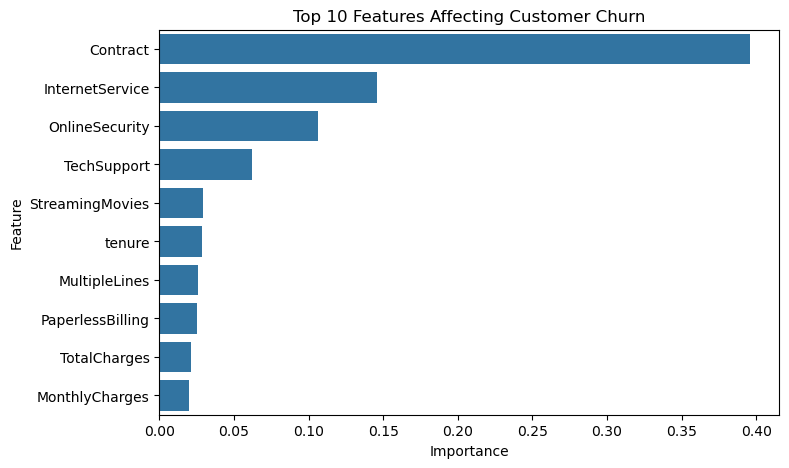

In [21]:
xgb_model = best_models['XGBoost']
importance = pd.DataFrame({
    'Feature': X_train_enc.columns,
    'Importance': xgb_model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
top10 = importance.head(10)
plt.figure(figsize=(8,5))
sns.barplot(data=top10,
            x='Importance',
            y='Feature')
plt.title('Top 10 Features Affecting Customer Churn')
plt.show()

In [22]:
import pickle

# Save best model
with open('churn_model.pkl', 'wb') as file:
    pickle.dump(best_models['XGBoost'], file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [23]:
print(X_train_enc.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [24]:
le_dict = {}

for col in cat_features:
    le = LabelEncoder()

    X_train_enc[col] = le.fit_transform(X_train[col])
    X_test_enc[col] = le.transform(X_test[col])

    le_dict[col] = le

In [25]:
import pickle

with open('label_encoders.pkl', 'wb') as file:
    pickle.dump(le_dict, file)

print("Encoders saved")

Encoders saved
